# 07 — Comparação Final dos Modelos de Probabilidade de Churn
## PRT Seguros

Compara os 6 modelos treinados nos notebooks `01`–`06`, todos avaliados no **mesmo split de
validação** e sobre o **mesmo conjunto de features** (gerado em `00_preparacao_dados.ipynb`).

**Métrica de decisão: AUC-ROC** — mede o quão bem o modelo ordena os indivíduos por probabilidade
de churn, que é o objetivo do projeto (não apenas acertar 0/1).

Ao final, geramos uma submissão Kaggle usando o **melhor modelo individual** (maior AUC-ROC sozinho).

> **Atenção:** isso é diferente da recomendação final de produção. O notebook
> `25_modelo_final_vencedor.ipynb` mostra que um **ensemble** (Random Forest + Extra Trees, os dois
> mais fracos individualmente aqui) generaliza melhor para dados novos do que qualquer modelo
> sozinho — inclusive o que "vence" nesta comparação. Esta comparação serve para entender o
> desempenho de cada modelo isoladamente; a recomendação de produção está no notebook `25`.


## 1. Carregar resultados dos 6 modelos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY  = "#737C8A"

resultados = pd.read_csv("dados_processados/resultados_modelos.csv")
resultados = resultados.sort_values("auc_roc_val", ascending=False).reset_index(drop=True)
resultados


,modelo,auc_roc_val
0,catboost,0.825413
1,xgboost,0.823997
2,lightgbm,0.823799
3,random_forest,0.819568
4,extra_trees,0.806200
5,logistic_regression,0.803300


## 2. Gráfico comparativo de AUC-ROC

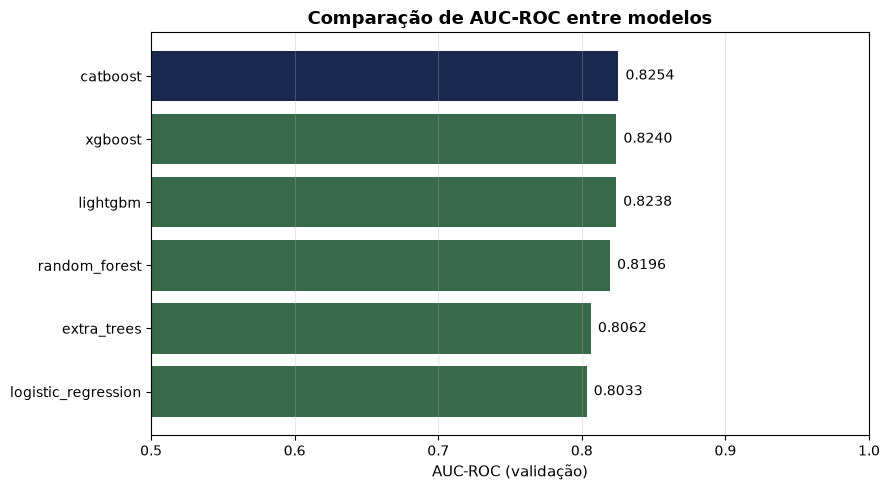


Melhor modelo: catboost (AUC-ROC = 0.8254)


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
cores = [PRT_NAVY if i == 0 else PRT_GREEN for i in range(len(resultados))]
ax.barh(resultados["modelo"], resultados["auc_roc_val"], color=cores)
ax.set_xlabel("AUC-ROC (validação)", fontsize=11)
ax.set_title("Comparação de AUC-ROC entre modelos", fontsize=13, fontweight="bold")
ax.set_xlim(0.5, 1.0)
for i, v in enumerate(resultados["auc_roc_val"]):
    ax.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=10)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

melhor_modelo = resultados.iloc[0]["modelo"]
melhor_auc = resultados.iloc[0]["auc_roc_val"]
print(f"\nMelhor modelo: {melhor_modelo} (AUC-ROC = {melhor_auc:.4f})")


## 3. Gerar submissão do melhor modelo individual

Usa as probabilidades já calculadas pelo notebook do melhor modelo individual (pasta
`submissions/`) — não precisamos retreinar aqui, só copiar o arquivo do modelo vencedor.

**Este NÃO é o arquivo de submissão recomendado para produção** — é só o melhor entre os 6 modelos
avaliados isoladamente. A submissão recomendada é `submissions/submission_FINAL_vencedor.csv`,
gerada pelo notebook `25_modelo_final_vencedor.ipynb`.

In [3]:
import shutil

origem = f"submissions/submission_{melhor_modelo}.csv"
destino = "submissions/submission_melhor_modelo_individual.csv"
shutil.copyfile(origem, destino)

final = pd.read_csv(destino)
print(f"Submissao do melhor modelo INDIVIDUAL: {melhor_modelo} (AUC-ROC = {melhor_auc:.4f})")
print("Para a submissao de producao recomendada, use submission_FINAL_vencedor.csv (notebook 25).")
print(f"Arquivo: {destino}")
final.head()


Submissao do melhor modelo INDIVIDUAL: catboost (AUC-ROC = 0.8254)
Para a submissao de producao recomendada, use submission_FINAL_vencedor.csv (notebook 25).
Arquivo: submissions/submission_melhor_modelo_individual.csv


,Id,probabilidade_churn
0,221300000002,0.090415
1,221300000020,0.297691
2,221300000097,0.133824
3,221300000148,0.373299
4,221300000166,0.275990


## 4. Distribuição das probabilidades previstas (modelo final)

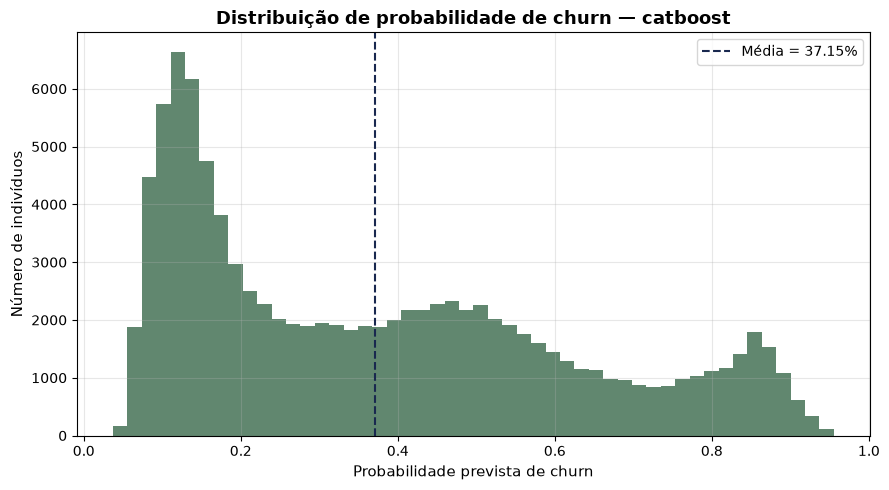

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(final["probabilidade_churn"], bins=50, color=PRT_GREEN, alpha=0.8)
ax.axvline(final["probabilidade_churn"].mean(), color=PRT_NAVY, linestyle="--",
           label=f"Média = {final['probabilidade_churn'].mean():.2%}")
ax.set_xlabel("Probabilidade prevista de churn", fontsize=11)
ax.set_ylabel("Número de indivíduos", fontsize=11)
ax.set_title(f"Distribuição de probabilidade de churn — {melhor_modelo}", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
